In [1]:
import os
os.getcwd()

'D:\\AJN\\NIBM\\HDSE\\IOT\\AgroSmart\\ML'

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv("Crop_recommendation.csv")

# Show first 5 rows
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
# Crops we want for AgroSmart
target_crops = ["chickpea", "kidneybeans", "mungbean"]

# Filter dataset
df_filtered = df[df["label"].isin(target_crops)]

# Check how many rows for each crop
df_filtered["label"].value_counts()


label
chickpea       100
kidneybeans    100
mungbean       100
Name: count, dtype: int64

In [5]:
# Select ALL input features
X = df_filtered[["N", "P", "K", "temperature", "humidity", "rainfall", "ph"]]

# Output labels
y = df_filtered["label"]

# Quick check
X.head(), y.head()


(      N   P   K  temperature   humidity   rainfall        ph
 200  40  72  77    17.024985  16.988612  88.551231  7.485996
 201  23  72  84    19.020613  17.131591  79.926981  6.920251
 202  39  58  85    17.887765  15.405897  68.549329  5.996932
 203  22  72  85    18.868056  15.658092  88.510490  6.391174
 204  36  67  77    18.369526  19.563810  79.263577  7.152811,
 200    chickpea
 201    chickpea
 202    chickpea
 203    chickpea
 204    chickpea
 Name: label, dtype: object)

In [7]:
from sklearn.preprocessing import LabelEncoder

# Create label encoder
label_encoder = LabelEncoder()

# Convert crop names to numbers
y_encoded = label_encoder.fit_transform(y)

# Show mapping
list(zip(label_encoder.classes_, range(len(label_encoder.classes_))))


[('chickpea', 0), ('kidneybeans', 1), ('mungbean', 2)]

In [8]:
# Check first 10 encoded labels
y_encoded[:10]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Check sizes
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((240, 7), (60, 7), (240,), (60,))

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create the model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5  # keep it simple and explainable
)

# Train (fit) the model
dt_model.fit(X_train, y_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_accuracy


0.9666666666666667

In [11]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

# Display as table
cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_df


,chickpea,kidneybeans,mungbean
chickpea,20,0,0
kidneybeans,0,18,2
mungbean,0,0,20


In [12]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=label_encoder.classes_
))


              precision    recall  f1-score   support

    chickpea       1.00      1.00      1.00        20
 kidneybeans       1.00      0.90      0.95        20
    mungbean       0.91      1.00      0.95        20

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

# Train model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_accuracy


1.0

In [14]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_rf_df


,chickpea,kidneybeans,mungbean
chickpea,20,0,0
kidneybeans,0,20,0
mungbean,0,0,20


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance values
feature_importance = rf_model.feature_importances_

# Create a table
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

importance_df


,Feature,Importance
2,K,0.241232
6,ph,0.221615
5,rainfall,0.182022
4,humidity,0.161741
3,temperature,0.147261
1,P,0.029195
0,N,0.016932


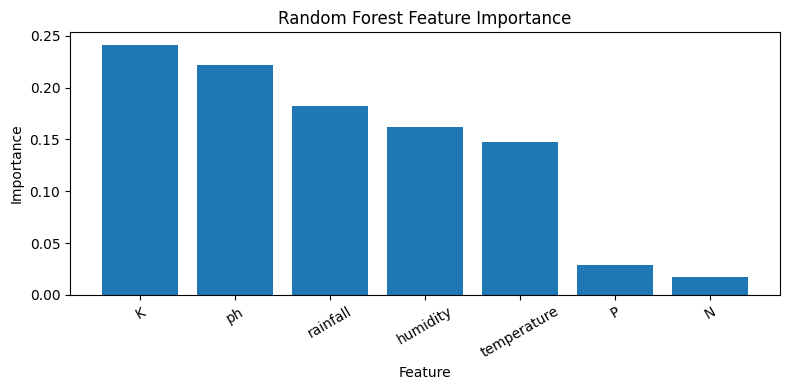

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [17]:
import joblib

# Save trained Random Forest model
joblib.dump(rf_model, "agrosmart_rf_crop_model.pkl")

# Save label encoder
joblib.dump(label_encoder, "agrosmart_label_encoder.pkl")

# Save feature order (important for correct predictions)
joblib.dump(list(X.columns), "agrosmart_feature_order.pkl")

print("Model, encoder, and feature order saved successfully.")


Model, encoder, and feature order saved successfully.
